In [1]:
import os,sys
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from plotnine import *
from pathlib import Path
import re
import glob

In [2]:
experiment_info = pd.read_csv('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/h5ad_raw_files_info.csv')
experiment_info = experiment_info.loc[:, ~experiment_info.columns.str.startswith("Unnamed")]
experiment_info.columns

Index(['lane1', 'lane2', 'lane3', 'lane4', 'lane5', 'lane6', 'lane7', 'lane8'], dtype='object')

In [3]:
name = []
for row in experiment_info.itertuples(index=False):
    tmp = []
    for k, v in row._asdict().items():
        t = v+'_'+k
        tmp.append(t)
    name.append(tmp)

In [4]:
def classify_sgrna(df):
    df['sgRNA_type'] = 'single sgRNA'
    # overwrite where gRNA is missing
    df.loc[df['assigned_guide_id'].isna(), 'sgRNA_type'] = 'no sgRNA'
    df.loc[df['assigned_guide_id'].str.startswith('NTC', na=False), 'sgRNA_type'] = 'single NTC sgRNA'
    df.loc[df_guide['assigned_guide_id'].str.startswith('multi', na=False), 'sgRNA_type'] = 'multi sgRNA'
    # Order the rows
    type_order = ['single sgRNA','single NTC sgRNA','multi sgRNA','no sgRNA']
    df['sgRNA_type'] = pd.Categorical(df['sgRNA_type'],categories=type_order,ordered=True)
    df = df.loc[:, ['lane_id','gRNA', 'assigned_guide_id', 'UMI_counts', 'target_gene','sgRNA_type']]
    return df

In [5]:
df1 = pd.DataFrame()
for i in range(0,len(name)):
    df = pd.DataFrame()
    for j in name[i]:
        path = f'/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/{j}/'
        guide_pattern = glob.glob(os.path.join(path, "*_gex_guide.h5ad"))[0]
        adata = sc.read_h5ad(os.path.join(path, guide_pattern))
        df_guide = adata.obs
        df_guide = classify_sgrna(df_guide)
        # df_guide['donor'] = j.split('_')[0]
        df_guide['construct'] = '_'.join(j.split('_')[:3])
        # df_guide['condition'] = j.split('_')[2]
        df = pd.concat([df, df_guide])
    df1 = pd.concat([df1, df])

In [6]:
def plot_lane_sgRNA(df):
    p = (ggplot(df,
               aes(x = 'construct', fill = 'sgRNA_type'))+
        geom_bar(position="stack")+
        scale_fill_brewer(type='sequential', palette= 5, direction= -1)+
        theme_bw()+
        theme(figure_size=(5, 3), dpi=150,axis_text_x=element_text(rotation=90, hjust=1)))
    return p

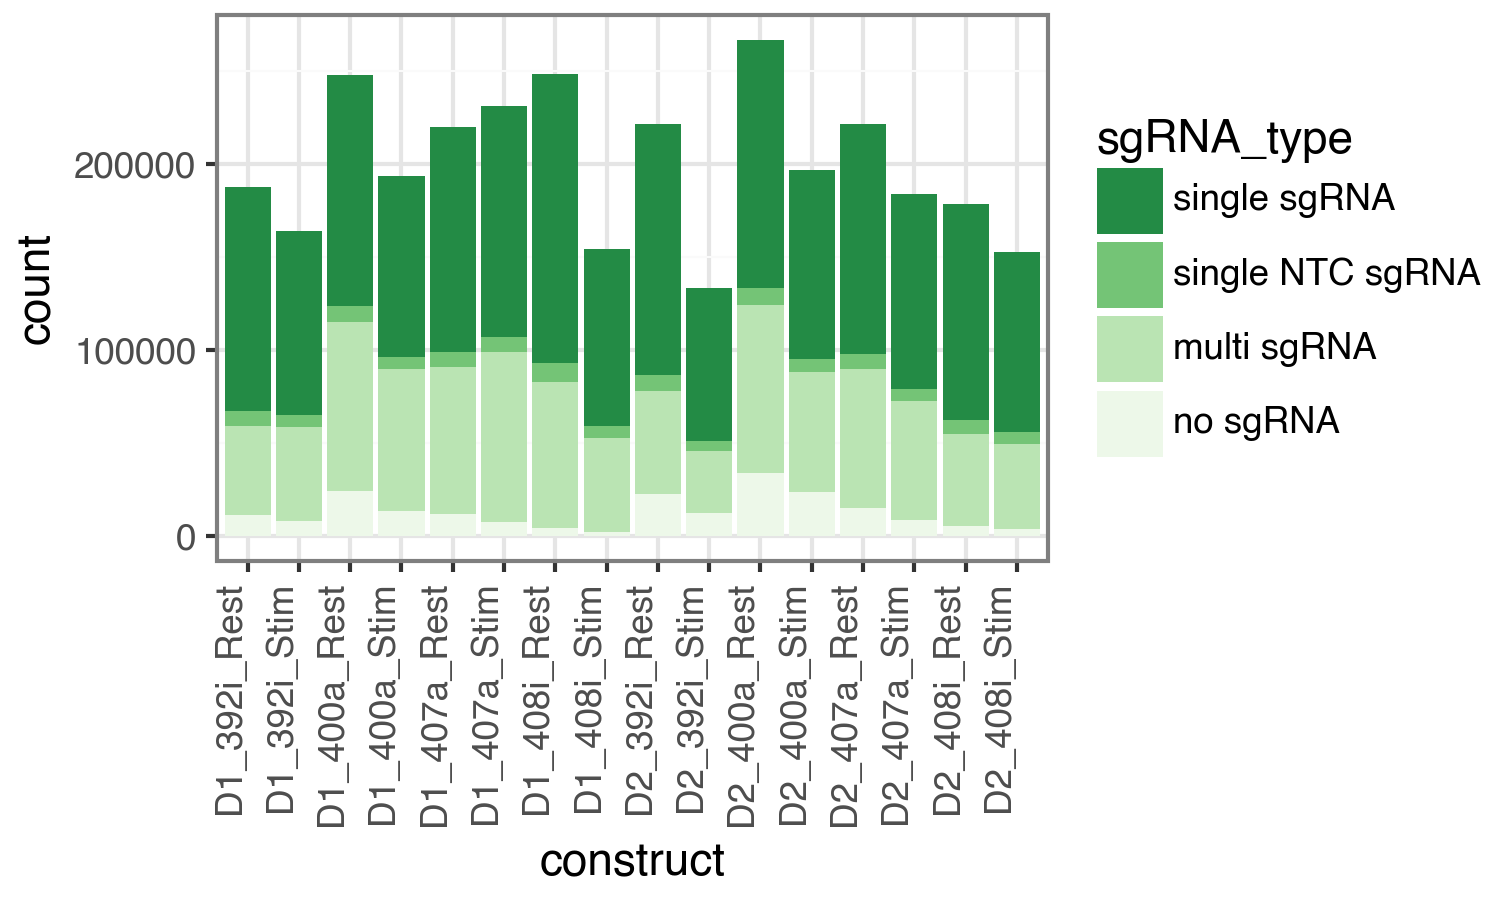

In [7]:
plot_pth = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/plots/'
os.makedirs(plot_pth, exist_ok= True)
plot_dis = plot_lane_sgRNA(df1)
# plot_dis.save(os.path.join(plot_pth, 'guide_distribution.png'))
plot_dis